## Artificial Neural Network for Customer Churn Prediction

**Project:** Predict whether a customer will churn using a feed-forward Artificial Neural Network (ANN).

Dataset: IBM Telco Customer Churn dataset  
Suggested source: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


## Setup



In [425]:
!pip install tensorflow scikit-learn pandas matplotlib seaborn -q


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## Imports and configuration

In [426]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
TARGET = "Churn"


#### Load and inspect the data


In [427]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')


In [428]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [429]:
df.shape

(7043, 21)

In [430]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [431]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [432]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [433]:
df.isnull().sum().sum()

np.int64(0)

In [434]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

- The dataset contains 7043 entries. 
- It has no duplicate values. 
- The target column is Churn. It is not balanced as the Yes (the number of customers that left within the last month) values are 1869 and the No (the number of customers retained) values are 5174.

#### Clean the data



In [435]:
df["TotalCharges"] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')


In [436]:
df = df.dropna(subset = ['TotalCharges'])
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [437]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [438]:
df.drop(columns=["customerID"], inplace=True)

In [439]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


#### Separate features and target


In [440]:
df[TARGET] = df[TARGET].map({
    'Yes' : 1, 'No' : 0
})


In [441]:
X = df.drop(columns = [TARGET])

In [442]:
y = df[TARGET]

In [443]:
print('X shape:', X.shape)

X shape: (7032, 19)


In [444]:
print('Y Shape:', y.shape)

Y Shape: (7032,)


In [445]:
print(y.value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


#### Encode categorical variables


In [446]:
X = pd.get_dummies(X, drop_first=True)

In [447]:
X.dtypes

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                 bool
Partner_Yes                                 bool
Dependents_Yes                              bool
PhoneService_Yes                            bool
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service             bool
TechSupport_Yes                             bool
StreamingTV_No inter

In [448]:
X.shape

(7032, 30)

#### Train / validation / test split


In [449]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size = 0.3, random_state = SEED, stratify = y
)


In [450]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size = 0.5, random_state = SEED, stratify = y
)

ValueError: Found input variables with inconsistent numbers of samples: [2110, 7032]

In [ ]:
print('X_train', X_train)

X_train       SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
3946              0       9           58.50        539.85        False   
3394              0      26           61.55       1581.95         True   
1635              0       3           69.95        220.45        False   
4088              0       7           73.60        520.00         True   
1886              0      67           60.40       3953.70         True   
...             ...     ...             ...           ...          ...   
3778              0       3           50.40        137.25         True   
5199              0      51          111.50       5703.25        False   
5235              0       9           81.15        784.45         True   
5399              0      50           19.75        989.05        False   
862               1      20           73.65       1463.50         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
3946        False           False             Fa

In [ ]:
print('X_temp', X_temp)

X_temp       SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
2481              1      61           25.00       1501.75         True   
6784              0      19           24.70        465.85        False   
6125              0      13          102.25       1359.00         True   
3052              0      37           55.05       2030.75         True   
4099              0       6           29.45        161.45        False   
...             ...     ...             ...           ...          ...   
2763              0      64           81.05       5135.35         True   
6747              0      52           35.45       1958.95        False   
1700              0      47           20.45        943.00         True   
1099              0       5           55.70        259.40         True   
4720              1      64          102.10       6688.10         True   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
2481         True           False              Tr

In [ ]:
print('X_val', X_val)

X_val       SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
1654              0       1           18.80         18.80         True   
3971              0      25           24.75        692.10        False   
2234              0      23           59.70       1414.20         True   
5204              1      38           24.85        955.75         True   
6027              0      35           25.45        809.25         True   
...             ...     ...             ...           ...          ...   
6677              0      13           29.15        357.15        False   
6636              0      10           70.30        676.15        False   
3320              1      18           59.10       1011.05         True   
2172              0       1           43.95         43.95        False   
3632              0      24           79.65       1928.70        False   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
1654         True            True              Tru

In [ ]:
print('X_test', X_test)

X_test       SeniorCitizen  tenure  MonthlyCharges  TotalCharges  gender_Male  \
3577              0      36           65.40       2498.40         True   
1881              0      26           44.65       1156.55         True   
2996              0      18           60.60       1156.35        False   
5428              0       9           89.45        853.10        False   
1112              1      71           89.85       6293.45        False   
...             ...     ...             ...           ...          ...   
3580              0       9           72.90        651.40        False   
3853              0      46           72.80       3249.40         True   
6121              0       8           19.50        159.35        False   
614               0      50           69.50       3418.20         True   
3054              0      67          106.60       7244.70        False   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
3577        False           False              Tr

#### Standardize the numerical inputs


In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = np.array(X_train_scaled)
X_val_scaled = np.array(X_val_scaled)
X_test_scaled = np.array(X_test_scaled)

In [ ]:
y_train = np.array(y_train)
y_val = np.array(y_val)
y_test = np.array(y_test)

#### Build the Artificial Neural Network


In [ ]:
def build_model(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation = 'relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation ='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation = 'sigmoid')
    ])

    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

    return model


In [ ]:
model = build_model(X_train_scaled.shape[1])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the ANN


In [ ]:
early_stop = EarlyStopping(
    monitor = 'val_loss', patience = 5, restore_best_weights = True
)


In [ ]:
history = model.fit(
    X_train_scaled,
    y_train, 
    validation_data = (X_val_scaled, y_val),
    epochs = 50,
    batch_size = 32,
    callbacks = [early_stop],
    verbose = 1
)

Epoch 1/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 1s 891us/step - accuracy: 0.7519 - loss: 0.4888 - val_accuracy: 0.7886 - val_loss: 0.4377
Epoch 2/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 475us/step - accuracy: 0.7885 - loss: 0.4485 - val_accuracy: 0.7991 - val_loss: 0.4281
Epoch 3/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 472us/step - accuracy: 0.7978 - loss: 0.4346 - val_accuracy: 0.7896 - val_loss: 0.4273
Epoch 4/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 470us/step - accuracy: 0.7911 - loss: 0.4337 - val_accuracy: 0.7953 - val_loss: 0.4272
Epoch 5/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 0.8041 - loss: 0.4210 - val_accuracy: 0.7972 - val_loss: 0.4258
Epoch 6/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 467us/step - accuracy: 0.8023 - loss: 0.4250 - val_accuracy: 0.7943 - val_loss: 0.4241
Epoch 7/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 0.8027 - loss: 0.4168 - val_accuracy: 0.7962 - val_loss: 0.4240
Epoch 8/50
154/154 ━━━━━━━━━━━━━━━━━━━━ 0s 468us/step - accuracy: 0.7989 - loss: 0.4156 - 

#### Plot training curves


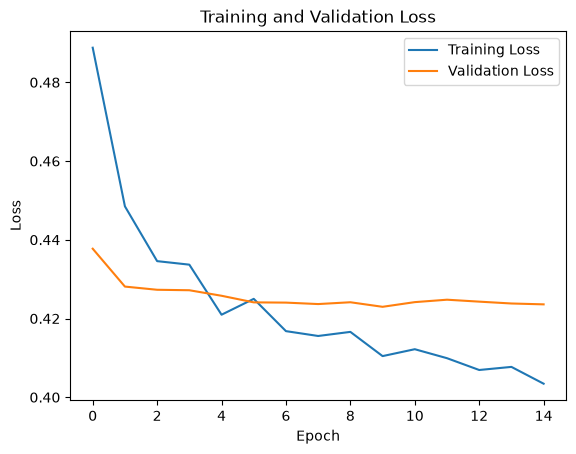

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()


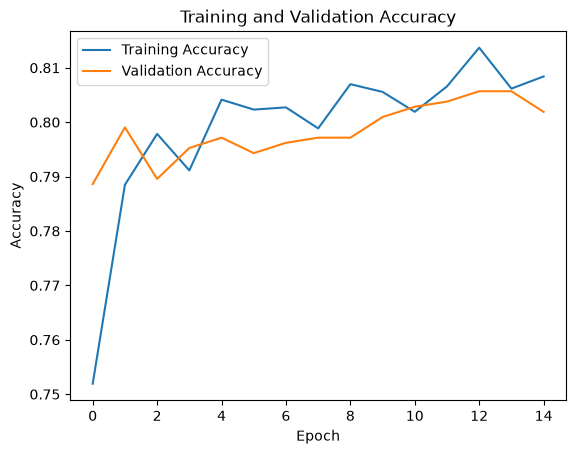

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

#### Evaluate on the test set



In [ ]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print('Testing Loss:', test_loss)
print('Testing Accuracy:', test_accuracy)


33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 462us/step - accuracy: 0.7896 - loss: 0.4464
Testing Loss: 0.44638267159461975
Testing Accuracy: 0.7895734310150146


In [ ]:
probabilities = model.predict(X_test_scaled)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 645us/step


In [ ]:
predictions = (probabilities >= 0.5).astype(int)

#### Confusion matrix


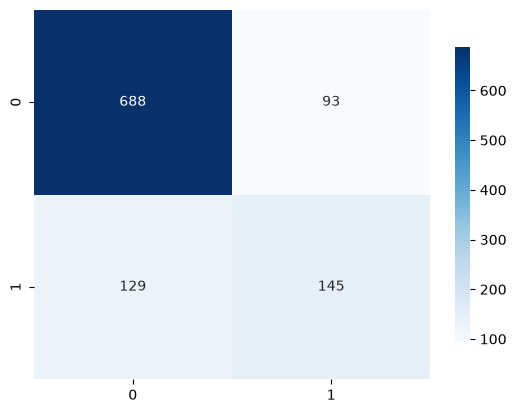

In [ ]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot= True, fmt = 'd', cmap = 'Blues', cbar_kws={"shrink": 0.8})
plt.show()



#### Experiment with the decision threshold



In [ ]:
from sklearn.metrics import precision_score, recall_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    prediction_thresholds = (probabilities >= threshold).astype(int)

    precision = precision_score(y_test, prediction_thresholds)

    recall = recall_score(y_test, prediction_thresholds)

    print('Threshold:', prediction_thresholds)
    print('Precision:', precision)
    print('Recall:', recall)
    


Threshold: [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
Precision: 0.5150753768844221
Recall: 0.7481751824817519
Threshold: [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
Precision: 0.5662251655629139
Recall: 0.6240875912408759
Threshold: [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
Precision: 0.6092436974789915
Recall: 0.5291970802919708
Threshold: [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
Precision: 0.6607142857142857
Recall: 0.4051094890510949
Threshold: [[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
Precision: 0.7325581395348837
Recall: 0.22992700729927007


#### Save the ANN



In [ ]:
model.save("customer_churn_ann.keras")
